In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from numpy import random
from InflGame.adaptive.visualization import Shell
import InflGame.utils.general as general
import InflGame.domains.rd as rd

## Resource distribution (beta)

In [2]:
#The resource points
bin_points=np.linspace(.001, .999, 100)





#resource parmaters
resource_parameters=[2,2] #alpha,beta

#Resource distribution
resource_distribution1=rd.resource_distribution_choice(bin_points=bin_points,resource_type='beta',resource_parameters=resource_parameters)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution1)
ax.set_box_aspect(1)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
plt.close()

## Resource distribution (Gaussian sym)

In [16]:
#The resource points
bin_points=np.linspace(.001, .999, 100)
alpha=.5
#Resource parameters
resource_parameters_gaussian=[[.1,.1],[.5-alpha/2,.5+alpha/2],[1,1]] #[[sd1, sd2,], [mean1,mean2], [factor1,factor2]]
#Resource distribution
resource_distribution2=rd.resource_distribution_choice(bin_points=bin_points,resource_type='multi_modal_gaussian_distribution_1D',resource_parameters=resource_parameters_gaussian)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution2)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
ax.set_box_aspect(1) 
#fig.savefig('1d_bimodal_alpha_05.svg',bbox_inches='tight')
plt.close()


## Resource distribution (Gaussian asym)

In [17]:
#The resource points
bin_points=np.linspace(.001, .999, 100)
 
#Resource parameters
resource_parameters_gaussian=[[.1,.1],[.25,.75],[1,.6]] #[[sd1, sd2,], [mean1,mean2], [factor1,factor2]]
#Resource distribution
resource_distribution3=rd.resource_distribution_choice(bin_points=bin_points,resource_type='multi_modal_gaussian_distribution_1D',resource_parameters=resource_parameters_gaussian)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution3)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
ax.set_box_aspect(1) 
#fig.savefig('1d_bimodal_alpha_05.svg',bbox_inches='tight')
plt.close()

## Resource distribution (Noisy)

In [18]:
#The resource points
random.seed(1)
bin_points=np.linspace(.001, .999, 100)

#smoothing kernal (resource parameter)
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth
y=np.abs(random.uniform(low=0,high=1,size=100)+random.normal(loc=.5,scale=.1,size=100))

#Resource distribution
resource_distribution4=smooth(y,box_pts=20)
domain=bin_points

#Plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_box_aspect(1)
ax.plot(domain,resource_distribution4)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
#fig.savefig('1d_bimodal_noisy.svg',bbox_inches='tight')
plt.close()

## Resource distribution (uniform)

In [19]:
#The resource points
bin_points=np.linspace(.001, .999, 100)
 
#Resource parameters
resource_parameters_gaussian=[[.1,.1],[.1,.5],[1,1]] #[[sd1, sd2,], [mean1,mean2], [factor1,factor2]]
#Resource distribution
resource_distribution5=rd.resource_distribution_choice(bin_points=bin_points,resource_type='multi_modal_gaussian_distribution_1D',resource_parameters=resource_parameters_gaussian)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution5)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
ax.set_box_aspect(1) 
#fig.savefig('1d_bimodal_alpha_05.svg',bbox_inches='tight')
plt.close()

In [20]:
#The resource points
bin_points=np.linspace(.001, .999, 100)

resource_distribution6=np.array([1]*len(bin_points))

#Plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_box_aspect(1)
ax.plot(domain,resource_distribution6)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
plt.close()

In [21]:
# bin_points=np.array([0,1])


# resource_distribution7=np.array([10,10])

# #Plot
# fig, ax = plt.subplots(figsize=(12, 8))
# ax.vlines(bin_points, 0, resource_distribution7, colors='b', lw=5)
# ax.set_box_aspect(1)
# ax.scatter(bin_points,resource_distribution7)
# plt.title('Resource distribution')
# plt.xlabel('loc')
# plt.ylabel('Resource density')


## Setup:The enviroment and adapative enviroment

The cell below sets up the outer shell for visualizing the the adapative enviroment. 

In [ ]:

domain_type='1d'
resource_distribution=resource_distribution2
mean=np.dot(bin_points,resource_distribution)/np.sum(resource_distribution) #mean of the resource distribution




num_agents=6 #number of agents
#int_agents_pos=general.agent_position_setup(num_agents=num_agents,setup_type='paper_default',domain_type=domain_type,domain_bounds=0)
int_agents_pos=torch.tensor([0.9255, 0.4816, 0.1969, 0.3216, 0.1931, 0.0655]) #initial agent positions

infl_configs={"infl_type":"gaussian"} # influence type of the agents

                
parameters=general.agent_parameter_setup(num_agents=num_agents,infl_type=infl_configs["infl_type"],setup_type="initial_symmetric_setup",reach=0.1) # parameters impacting agents reach (their std)
#parameters_custom=np.array([[.1,.2,.3,...]]) #needs to be length num_players


time_steps=3000# number steps for the adaptive dynamics


vis=Shell(num_agents=num_agents,agents_pos=int_agents_pos,parameters=parameters,resource_distribution=resource_distribution,bin_points=bin_points, 
infl_configs = {'infl_type': 'gaussian'}, learning_rate_type= 'cosine_annealing', learning_rate= [.001, .001, 3000], time_steps=time_steps,
fp= 0, infl_cshift= False, cshift = 0, infl_fshift= False, Q = None,
domain_type = '1d', domain_bounds = [0, 1], resource_type = 'na', domain_refinement = 10,
tolerance = 10**-10, tolerated_agents = None,ignore_zero_infl= True)


vis.setup_adaptive_env()
vis.field.gradient_ascent()
og_pos_matrix=vis.field.pos_matrix
og_grad_matrix=vis.field.grad_matrix
vis.agents_pos=int_agents_pos.clone()
vis.field.agents_pos=int_agents_pos.clone()

        

        



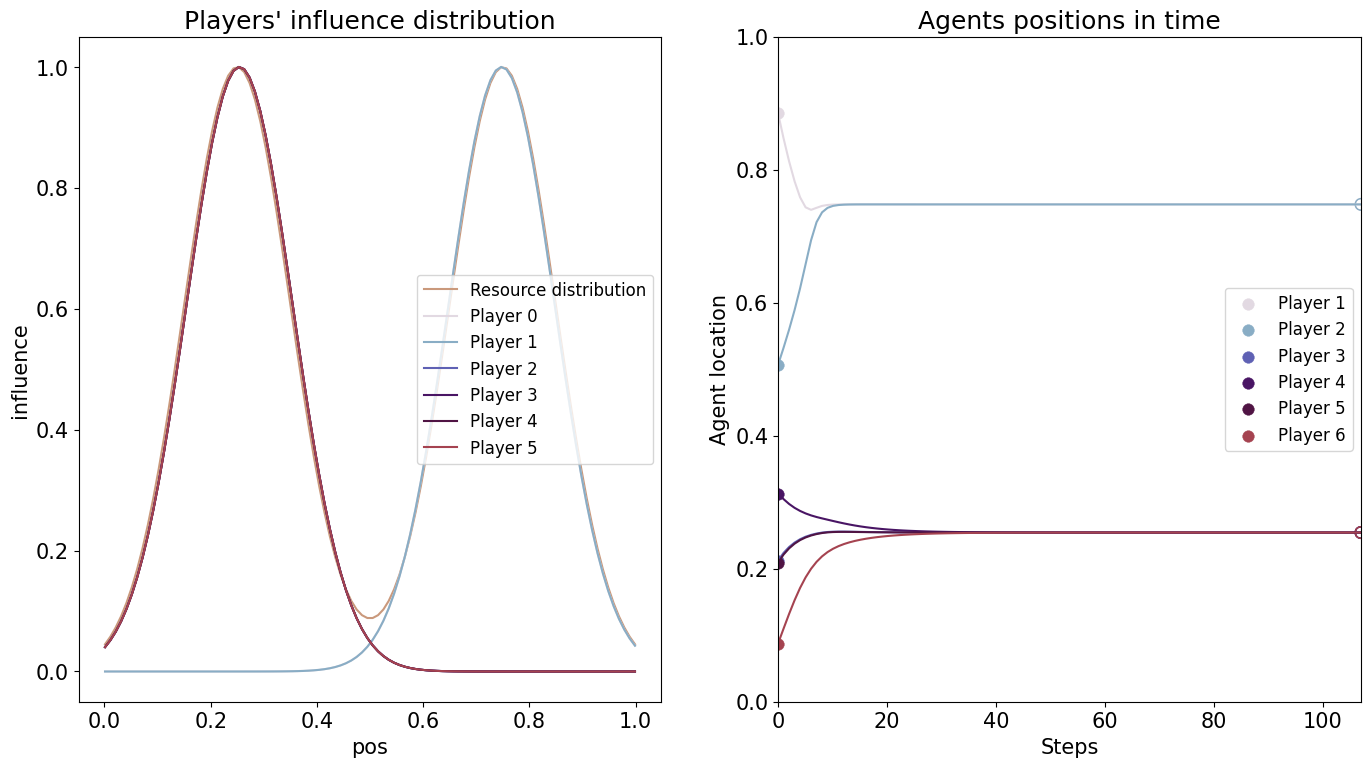

In [24]:
vis.dist_pos_gif(1)

In [55]:
import hickle as hkl
from InflGame.adaptive import eq_class as eqc 

#region  1 :  alpha=.5 sigma=.18
#region  2 :  alpha=.5 sigma=.1
#region 3_8:  alpha =.8 , sigma =.20
#region 4_8 alpha=.8 sigma=.15



region_num=4_8
search=eqc.search_env(vis.num_agents,vis.agents_pos,vis.parameters,vis.resource_distribution,vis.bin_points,
              vis.infl_configs,vis.learning_rate_type,vis.learning_rate,vis.time_steps,fp= 0, infl_cshift= False, cshift = 0, infl_fshift= False, Q = None,
              domain_type = '1d', domain_bounds = [0, 1], resource_type = 'na', domain_refinement = 10,
              tolerance = 10**-12, tolerated_agents = None,ignore_zero_infl= True)
#results = search.search_Eq(resolution=10, num_workers=12,time_steps=3000, use_monte_carlo=True,number_samples=20000,seed=42)
#hkl.dump(results,f'region{region_num}_gaussian_stats.hkl')

                                                                                                                                                                                                                                             

In [56]:
results=hkl.load(f'region{region_num}_gaussian_stats.hkl')
#sigs=0.25,0.17,0.1
#lr=[.001, .001, 80],[.001, .001, 80],[.001, .001, 80],[.0001, .0001, 80]

In [57]:
#region 3_8: sigs=0.2
#region 2_8: sigs=0.27
intial_pos=search.monte_carlo_unit_hypercube(number_samples=20000,seed=42)
intial_pos[738]

tensor([0.0278, 0.1513, 0.0163, 0.8290, 0.3250, 0.3650])

In [33]:
pos_lst=[]
for i in results:
    pos_lst.append(results[i]['pos_converged'])
pos_lst=np.array(pos_lst)

In [34]:
import InflGame.domains.one_d.one_utils as one_utils
resource_parameters=[[.2]*6]*len(results)
clarification=one_utils._type_dict_helper(matrix=pos_lst,reach_parameters=np.array(resource_parameters),tolerance=1e-2)
classification=one_utils.classification_helper(clarification)

AttributeError: module 'InflGame.domains.one_d.one_utils' has no attribute 'classification_helper'

In [58]:
import numpy as np
from collections import Counter

def analyze_grid_search_results(results_dict, position_tolerance=1e-3):
    """
    Analyze grid search results to classify equilibrium types and provide statistics.
    
    Args:
        results_dict: Dictionary from grid_search_Eq containing convergence results
        position_tolerance: Tolerance for considering positions as "equal"
    
    Returns:
        Dictionary with statistics and classifications
    """
    
    total_points = len(results_dict)
    cycles = 0
    converged = 0
    no_result = 0
    
    equilibrium_types = []
    convergence_positions = []
    
    for key, result in results_dict.items():
        if result is None:
            no_result += 1
            continue
            
        if not result.get('converged', False):
            if result.get('pos_converged') == 'cycle':
                cycles += 1
            else:
                no_result += 1  # Didn't converge and no cycle detected
        else:
            converged += 1
            pos = result.get('pos_converged')
            if pos is not None:
                convergence_positions.append(pos)
                
                # Classify equilibrium type based on position clustering
                eq_type = classify_equilibrium_type(pos, position_tolerance)
                equilibrium_types.append(eq_type)
    
    # Calculate percentages
    cycle_percentage = (cycles / total_points) * 100
    converged_percentage = (converged / total_points) * 100
    no_result_percentage = (no_result / total_points) * 100
    
    # Count equilibrium types
    eq_type_counts = Counter(equilibrium_types)
    eq_type_percentages = {eq_type: (count / converged) * 100 if converged > 0 else 0 
                          for eq_type, count in eq_type_counts.items()}
    
    return {
        'total_points': total_points,
        'cycles': cycles,
        'converged': converged,
        'no_result': no_result,
        'cycle_percentage': cycle_percentage,
        'converged_percentage': converged_percentage,
        'no_result_percentage': no_result_percentage,
        'equilibrium_types': dict(eq_type_counts),
        'equilibrium_type_percentages': eq_type_percentages,
        'convergence_positions': convergence_positions
    }

def classify_equilibrium_type(positions, tolerance=1e-3):
    """
    Classify equilibrium type based on how many agents share similar positions,
    distinguishing between different spatial arrangements.
    
    Args:
        positions: Array of agent positions
        tolerance: Tolerance for considering positions as equal
    
    Returns:
        String describing equilibrium type with position ordering:
        - '(n)' : All agents together
        - '(n-1,1)' : n-1 agents grouped at lower position, 1 isolated higher
        - '(1,n-1)' : 1 agent isolated at lower position, n-1 grouped higher
        - 'c(1,n-2,1)' : Middle group centered around 0.5
        - 'l(1,n-2,1)' : Middle group below 0.5
        - 'u(1,n-2,1)' : Middle group above 0.5
        - etc.
    """
    positions = np.array(positions)
    n_agents = len(positions)
    
    # Sort positions for easier comparison
    sorted_pos = np.sort(positions)
    
    # Group positions that are within tolerance
    groups = []
    group_positions = []  # Store mean position of each group
    current_group = [sorted_pos[0]]
    
    for i in range(1, len(sorted_pos)):
        if abs(sorted_pos[i] - current_group[-1]) <= tolerance:
            current_group.append(sorted_pos[i])
        else:
            groups.append(len(current_group))
            group_positions.append(np.mean(current_group))
            current_group = [sorted_pos[i]]
    
    # Don't forget the last group
    groups.append(len(current_group))
    group_positions.append(np.mean(current_group))
    
    # Now classify based on group structure and positions
    num_groups = len(groups)
    
    # Case 1: All agents at same position
    if num_groups == 1:
        return f'({n_agents})'
    
    # Case 2: Two groups - distinguish by which is larger and positions
    elif num_groups == 2:
        larger_group = max(groups)
        smaller_group = min(groups)
        
        # Find which group is at lower position
        if groups[0] > groups[1]:  # First (lower position) group is larger
            # (n-1, 1) pattern - most agents at lower position
            if larger_group == n_agents - 1:
                return f'({n_agents-1},1)'
            else:
                return f'({larger_group},{smaller_group})'
        else:  # Second (higher position) group is larger
            # (1, n-1) pattern - most agents at higher position
            if larger_group == n_agents - 1:
                return f'(1,{n_agents-1})'
            else:
                return f'({smaller_group},{larger_group})'
    
    # Case 3: Three groups - special case (1, n-2, 1) with position checks
    elif num_groups == 3:
        # Check if it's a (1, n-2, 1) pattern
        if groups[0] == 1 and groups[2] == 1:
            middle_group_size = groups[1]
            middle_position = group_positions[1]
            
            # Check position of middle group relative to 0.5
            if abs(middle_position - 0.5) < tolerance * 2:
                # Middle group centered around 0.5
                if middle_group_size == n_agents - 2:
                    return f'c(1,{n_agents-2},1)'
                else:
                    return f'c(1,{middle_group_size},1)'
            elif middle_position < 0.5:
                # Middle group below 0.5
                if middle_group_size == n_agents - 2:
                    return f'l(1,{n_agents-2},1)'
                else:
                    return f'l(1,{middle_group_size},1)'
            else:
                # Middle group above 0.5
                if middle_group_size == n_agents - 2:
                    return f'u(1,{n_agents-2},1)'
                else:
                    return f'u(1,{middle_group_size},1)'
        else:
            # General three-group pattern, sorted by size
            sorted_groups = sorted(groups, reverse=True)
            return f'({",".join(map(str, sorted_groups))})'
    
    # Case 4: More than three groups - just list sizes
    else:
        sorted_groups = sorted(groups, reverse=True)
        return f'({",".join(map(str, sorted_groups))})'

def print_results_summary(stats):
    """
    Print a formatted summary of the analysis results with enhanced descriptions
    for position-aware equilibrium types.
    """
    print("="*70)
    print("GRID SEARCH EQUILIBRIUM ANALYSIS RESULTS")
    print("="*70)
    print(f"Total starting points analyzed: {stats['total_points']}")
    print()
    
    print("CONVERGENCE BEHAVIOR:")
    print(f"  Converged to equilibrium: {stats['converged']:4d} ({stats['converged_percentage']:5.1f}%)")
    print(f"  Cycling behavior:        {stats['cycles']:4d} ({stats['cycle_percentage']:5.1f}%)")
    print(f"  No clear result:         {stats['no_result']:4d} ({stats['no_result_percentage']:5.1f}%)")
    print()
    
    if stats['converged'] > 0:
        print("EQUILIBRIUM TYPES:")
        print("  Type                Count   Percentage   Description")
        print("  ----                -----   ----------   -----------")
        
        def get_description(eq_type_str):
            """Generate human-readable description from equilibrium type string."""
            
            # Handle special position-aware types with short prefixes
            if eq_type_str.startswith('l(') and eq_type_str.count(',') == 2:
                # e.g., 'l(1,n-2,1)' or 'l(1,1,1)'
                parts = eq_type_str[2:-1].split(',')  # Remove 'l(' and ')'
                return f"{parts[0]} low, {parts[1]} grouped below 0.5, {parts[2]} high"
            
            elif eq_type_str.startswith('c(') and eq_type_str.count(',') == 2:
                # e.g., 'c(1,n-2,1)' or 'c(1,1,1)'
                parts = eq_type_str[2:-1].split(',')  # Remove 'c(' and ')'
                return f"{parts[0]} low, {parts[1]} at center (~0.5), {parts[2]} high"
            
            elif eq_type_str.startswith('u(') and eq_type_str.count(',') == 2:
                # e.g., 'u(1,n-2,1)' or 'u(1,1,1)'
                parts = eq_type_str[2:-1].split(',')  # Remove 'u(' and ')'
                return f"{parts[0]} low, {parts[1]} grouped above 0.5, {parts[2]} high"
            
            # Handle standard tuple notation
            elif eq_type_str.startswith('(') and eq_type_str.endswith(')'):
                groups_str = eq_type_str.strip('()').split(',')
                
                if len(groups_str) == 1:
                    return f"All {groups_str[0]} agents at same position"
                
                elif len(groups_str) == 2:
                    # Two groups - determine spatial arrangement
                    size1, size2 = groups_str[0].strip(), groups_str[1].strip()
                    # Assume larger group determines position
                    try:
                        n1, n2 = int(size1) if size1.isdigit() else None, int(size2) if size2.isdigit() else None
                        if n1 and n2:
                            if n1 > n2:
                                return f"{size1} agents at lower position, {size2} isolated higher"
                            else:
                                return f"{size1} isolated at lower position, {size2} agents grouped higher"
                    except:
                        pass
                    return f"{size1} and {size2} agents in separate groups"
                
                # Build description for multiple groups
                group_desc = []
                for size in groups_str:
                    size = size.strip()
                    if size == '1':
                        group_desc.append('1 agent')
                    else:
                        group_desc.append(f'{size} agents together')
                
                return ', '.join(group_desc)
            
            # Fallback
            return eq_type_str
        
        # Sort by count (descending) for better readability
        sorted_types = sorted(stats['equilibrium_types'].items(), 
                            key=lambda x: x[1], reverse=True)
        
        for eq_type, count in sorted_types:
            percentage = stats['equilibrium_type_percentages'][eq_type]
            description = get_description(eq_type)
            # Adjust spacing for longer type names
            print(f"  {eq_type:18s}  {count:5d}   {percentage:8.1f}%   {description}")
    
    print("="*70)
    

# Analyze the results
if 'results' in globals() and results:
    stats = analyze_grid_search_results(results)
    print_results_summary(stats)
else:
    print("No results found. Please run the grid search first.")

GRID SEARCH EQUILIBRIUM ANALYSIS RESULTS
Total starting points analyzed: 20000

CONVERGENCE BEHAVIOR:
  Converged to equilibrium: 20000 (100.0%)
  Cycling behavior:           0 (  0.0%)
  No clear result:            0 (  0.0%)

EQUILIBRIUM TYPES:
  Type                Count   Percentage   Description
  ----                -----   ----------   -----------
  (3,3)                7951       39.8%   3 isolated at lower position, 3 agents grouped higher
  (4,2)                5199       26.0%   4 agents at lower position, 2 isolated higher
  (2,4)                5190       25.9%   2 isolated at lower position, 4 agents grouped higher
  (5,1)                 839        4.2%   5 agents at lower position, 1 isolated higher
  (1,5)                 821        4.1%   1 isolated at lower position, 5 agents grouped higher


In [49]:
t=torch.tensor(results['972']['pos_converged'])

In [50]:
t

tensor([0.8707, 0.8707, 0.1329, 0.1329, 0.1329, 0.1329])

In [51]:
results

{'0': {'converged': True,
  'pos_converged': array([0.8670673 , 0.8670673 , 0.12933521, 0.8670673 , 0.12933521,
         0.86706656], dtype=float32)},
 '1': {'converged': True,
  'pos_converged': array([0.12933521, 0.8670673 , 0.8670673 , 0.12933521, 0.8670673 ,
         0.86706656], dtype=float32)},
 '2': {'converged': True,
  'pos_converged': array([0.86973155, 0.13026875, 0.86973107, 0.13026862, 0.86973155,
         0.13026875], dtype=float32)},
 '3': {'converged': True,
  'pos_converged': array([0.13293298, 0.87066495, 0.13293298, 0.13293314, 0.13293298,
         0.87066495], dtype=float32)},
 '4': {'converged': True,
  'pos_converged': array([0.13293296, 0.13293312, 0.87066454, 0.13293312, 0.87066454,
         0.13293296], dtype=float32)},
 '5': {'converged': True,
  'pos_converged': array([0.8670673 , 0.12933521, 0.8670673 , 0.86706656, 0.12933521,
         0.8670673 ], dtype=float32)},
 '6': {'converged': True,
  'pos_converged': array([0.8670666, 0.8670673, 0.8670666, 0.1293352

In [52]:
t=search.monte_carlo_unit_hypercube(number_samples=10000,seed=42)[972]

In [59]:
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Dict, Optional
import matplotlib.figure
from InflGame.utils import data_management

def plot_equilibrium_analysis(
    stats: Dict,
    plot_types: List[str] = ['convergence', 'distribution', 'percentage'],
    save: bool = False,
    name_ads: List[str] = [],
    save_types: List[str] = ['.png', '.svg'],
    paper_figure: Dict = {'paper': False, 'section': 'equilibrium_analysis', 'figure_id': 'equilibrium_analysis'},
    font: Dict = {
        'default_size': 12,
        'title_size': 14,
        'label_size': 11,
        'tick_size': 10,
        'font_family': 'sans-serif'
    },
    colors: Dict = {
        'converged': '#2E8B57',
        'cycling': '#FF6B6B',
        'no_result': '#95A5A6',
        'bar_distribution': '#3498DB',
        'bar_percentage': '#E74C3C'
    },
    text_configs: Dict = {
        'convergence_title': 'Convergence Behavior Distribution',
        'distribution_title': 'Equilibrium Types Distribution',
        'percentage_title': 'Equilibrium Types (% of Converged)',
        'xlabel_distribution': 'Equilibrium Type',
        'ylabel_distribution': 'Count',
        'xlabel_percentage': 'Equilibrium Type',
        'ylabel_percentage': 'Percentage (%)'
    },
    figsize: Optional[tuple] = None
) -> matplotlib.figure.Figure:
    """
    Create comprehensive visualizations of equilibrium analysis results.
    
    Parameters
    ----------
    stats : Dict
        Statistics dictionary containing convergence results and equilibrium types.
    plot_types : List[str], optional
        List of plot types to include: 'convergence', 'distribution', 'percentage'.
        Default is all three.
    save : bool, optional
        Whether to save the figure. Default is False.
    name_ads : List[str], optional
        List of additional name components for file naming. Default is [].
    save_types : List[str], optional
        File extensions for saving. Default is ['.png', '.svg'].
    paper_figure : Dict, optional
        Dictionary with keys 'paper' (bool), 'section' (str), 'figure_id' (str).
        Controls paper-style naming and organization. Default is 
        {'paper': False, 'section': 'equilibrium_analysis', 'figure_id': 'equilibrium_analysis'}.
    font : Dict, optional
        Font configuration dictionary with keys: 'default_size', 'title_size',
        'label_size', 'tick_size', 'font_family'.
    colors : Dict, optional
        Color configuration for different plot elements.
    text_configs : Dict, optional
        Text configuration for titles and labels.
    figsize : Optional[tuple], optional
        Figure size. If None, automatically determined based on number of plots.
    
    Returns
    -------
    matplotlib.figure.Figure
        The generated matplotlib figure.
    
    Examples
    --------
    >>> # Show only convergence pie chart
    >>> fig = plot_equilibrium_analysis(stats, plot_types=['convergence'])
    >>> 
    >>> # Show distribution and percentage, save with custom naming
    >>> fig = plot_equilibrium_analysis(
    ...     stats,
    ...     plot_types=['distribution', 'percentage'],
    ...     save=True,
    ...     name_ads=['gaussian', 'n3'],
    ...     paper_figure={'paper': True, 'section': 'results', 'figure_id': 'eq_analysis'}
    ... )
    """
    
    # Validate plot_types
    valid_types = ['convergence', 'distribution', 'percentage']
    plot_types = [pt for pt in plot_types if pt in valid_types]
    
    if not plot_types:
        raise ValueError(f"No valid plot types specified. Valid types: {valid_types}")
    
    num_plots = len(plot_types)
    
    # Determine figure size - fixed subplot dimensions
    if figsize is None:
        # Each subplot gets equal size: 5x5 inches
        subplot_width = 5
        subplot_height = 5
        # Add spacing between subplots
        total_width = num_plots * subplot_width + (num_plots - 1) * 0.5
        figsize = (total_width, subplot_height)
    
    # Create figure with GridSpec for precise control
    fig = plt.figure(figsize=figsize)
    
    # Calculate subplot positions to ensure equal sizes
    subplot_width_ratio = 1.0 / num_plots
    axes = []
    for i in range(num_plots):
        # Each subplot gets equal width fraction of the figure
        left = i * subplot_width_ratio + 0.05 / num_plots
        bottom = 0.15
        width = subplot_width_ratio * 0.85
        height = 0.7
        ax = fig.add_axes([left, bottom, width, height])
        axes.append(ax)
    
    # Set font
    plt.rcParams['font.family'] = font.get('font_family', 'sans-serif')
    plt.rcParams['font.size'] = font.get('default_size', 12)
    
    plot_idx = 0
    
    # Plot 1: Convergence behavior (pie chart)
    if 'convergence' in plot_types:
        ax = axes[plot_idx]
        plot_idx += 1

        label_names = ['Converged', 'Cycling', 'No Result']
        sizes = [stats['converged'], stats['cycles'], stats['no_result']]
        pie_colors = [colors['converged'], colors['cycling'], colors['no_result']]
        
        wedges, texts = ax.pie(
            sizes, startangle=90,
            colors=pie_colors,
            wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
        )
        
        # Custom label positioning with percentages
        _add_custom_pie_labels(ax, wedges, label_names, sizes, font)
        
        # Fix axis limits to prevent resizing when labels change
        ax.set_xlim(-1.6, 1.6)
        ax.set_ylim(-1.6, 1.6)
        ax.set_aspect('equal')
        
        ax.set_title(
            text_configs.get('convergence_title', 'Convergence Behavior Distribution'),
            fontsize=font.get('title_size', 14),
            fontweight='bold'
        )
    
    # Plot 2: Equilibrium types distribution (bar chart)
    if 'distribution' in plot_types:
        ax = axes[plot_idx]
        plot_idx += 1
        
        if stats['equilibrium_types']:
            eq_types = list(stats['equilibrium_types'].keys())
            eq_counts = list(stats['equilibrium_types'].values())
            
            bars = ax.bar(eq_types, eq_counts, color=colors['bar_distribution'], alpha=0.7)
            ax.set_title(
                text_configs.get('distribution_title', 'Equilibrium Types Distribution'),
                fontsize=font.get('title_size', 14),
                fontweight='bold'
            )
            ax.set_xlabel(
                text_configs.get('xlabel_distribution', 'Equilibrium Type'),
                fontsize=font.get('label_size', 11)
            )
            ax.set_ylabel(
                text_configs.get('ylabel_distribution', 'Count'),
                fontsize=font.get('label_size', 11)
            )
            ax.tick_params(axis='x', rotation=45, labelsize=font.get('tick_size', 10))
            ax.tick_params(axis='y', labelsize=font.get('tick_size', 10))
            
            # Add value labels on bars
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                       f'{int(height)}', ha='center', va='bottom',
                       fontsize=font.get('tick_size', 10))
        else:
            ax.set_visible(False)
    
    # Plot 3: Equilibrium type percentages (bar chart)
    if 'percentage' in plot_types:
        ax = axes[plot_idx]
        plot_idx += 1
        
        if stats['equilibrium_type_percentages']:
            eq_types = list(stats['equilibrium_type_percentages'].keys())
            eq_percentages = list(stats['equilibrium_type_percentages'].values())
            
            bars = ax.bar(eq_types, eq_percentages, color=colors['bar_percentage'], alpha=0.7)
            ax.set_title(
                text_configs.get('percentage_title', 'Equilibrium Types (% of Converged)'),
                fontsize=font.get('title_size', 14),
                fontweight='bold'
            )
            ax.set_xlabel(
                text_configs.get('xlabel_percentage', 'Equilibrium Type'),
                fontsize=font.get('label_size', 11)
            )
            ax.set_ylabel(
                text_configs.get('ylabel_percentage', 'Percentage (%)'),
                fontsize=font.get('label_size', 11)
            )
            ax.tick_params(axis='x', rotation=45, labelsize=font.get('tick_size', 10))
            ax.tick_params(axis='y', labelsize=font.get('tick_size', 10))
            
            # Add percentage labels on bars
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                       f'{height:.1f}%', ha='center', va='bottom',
                       fontsize=font.get('tick_size', 10))
        else:
            ax.set_visible(False)
    
    # Don't use tight_layout since we want fixed subplot sizes
    # plt.tight_layout() removed
    
    # Save figure if requested
    if save:
        # Get num_agents from stats if available, otherwise use a default
        num_agents = stats.get('num_agents', 3)
        domain_type = stats.get('domain_type', '1d')
        
        # Build data_parameters dictionary for data_management
        data_parameters = {
            'data_type': 'plot',
            'plot_type': 'equilibrium_analysis',
            'domain_type': domain_type,
            'num_agents': num_agents,
            'section': paper_figure.get('section', 'equilibrium_analysis'),
            'figure_id': paper_figure.get('figure_id', 'equilibrium_analysis')
        }
        
        # Generate file names using data_management
        file_names = data_management.data_final_name(
            data_parameters=data_parameters,
            name_ads=name_ads,
            save_types=save_types,
            paper_figure=paper_figure.get('paper', False)
        )
        
        # Save figure with all specified extensions
        for file_name in file_names:
            fig.savefig(file_name, bbox_inches='tight', dpi=300)
            print(f"Figure saved: {file_name}")
    
    return fig


def _add_custom_pie_labels(ax, wedges, labels, sizes, font):
    """Helper function to add custom positioned labels with connecting lines to pie chart."""
    label_positions = []
    total = sum(sizes)
    
    # Calculate angular positions for each wedge
    for wedge, size, label in zip(wedges, sizes, labels):
        if size == 0:  # Skip zero slices
            continue
            
        # Get the angle at the middle of the wedge
        angle = (wedge.theta2 + wedge.theta1) / 2.0
        
        # Calculate position on the pie edge
        x_pie = np.cos(np.radians(angle))
        y_pie = np.sin(np.radians(angle))
        
        # Calculate initial label position (radial distance from center)
        label_distance = 1.15
        x_label = label_distance * x_pie
        y_label = label_distance * y_pie
        
        # Determine horizontal alignment based on position
        ha = 'left' if x_label > 0 else 'right'
        
        # Calculate percentage
        percentage = (size / total) * 100 if total > 0 else 0
        label_with_pct = f'{label}\n{percentage:.1f}%'
        
        label_positions.append({
            'label': label_with_pct,
            'x_pie': x_pie * 1.0,
            'y_pie': y_pie * 1.0,
            'x_label': x_label,
            'y_label': y_label,
            'ha': ha,
            'angle': angle
        })
    
    # Adjust overlapping labels
    label_positions = _adjust_label_positions(label_positions)
    
    # Draw labels and connecting lines
    for pos in label_positions:
        # Draw line from pie edge to label
        ax.plot([pos['x_pie'], pos['x_label']], 
               [pos['y_pie'], pos['y_label']], 
               color='gray', linewidth=0.8, linestyle='-', zorder=0)
        
        # Draw label text
        ax.text(pos['x_label'], pos['y_label'], pos['label'],
               ha=pos['ha'], va='center', 
               fontsize=font.get('default_size', 12),
               fontweight='normal',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                        edgecolor='gray', alpha=0.8))


def _adjust_label_positions(positions, min_separation=0.15):
    """Helper function to adjust label positions to avoid overlaps."""
    if len(positions) <= 1:
        return positions
    
    # Sort by y position
    positions = sorted(positions, key=lambda p: p['y_label'])
    
    # Iteratively adjust overlapping labels
    max_iterations = 10
    for _ in range(max_iterations):
        adjusted = False
        for i in range(len(positions) - 1):
            curr = positions[i]
            next_pos = positions[i + 1]
            
            # Check if labels overlap vertically
            y_diff = abs(next_pos['y_label'] - curr['y_label'])
            if y_diff < min_separation:
                # Push labels apart
                adjustment = (min_separation - y_diff) / 2
                curr['y_label'] -= adjustment
                next_pos['y_label'] += adjustment
                adjusted = True
        
        if not adjusted:
            break
    
    # Adjust horizontal positions based on which side they're on
    for pos in positions:
        # Push labels further out horizontally to reduce crowding
        if pos['x_label'] > 0:
            pos['x_label'] = max(pos['x_label'], 1.15)
        else:
            pos['x_label'] = min(pos['x_label'], -1.15)
    
    return positions




Figure saved: C:\Users\Mark-Fu-Lab\Dartmouth College Dropbox\Mark Lovett\Mark-Fu Lab\influencer_games\src\InflGame\utils\paper_plots\3_1_3\fig313_c\1d_equilibrium_analysis_3_agents.png
Figure saved: C:\Users\Mark-Fu-Lab\Dartmouth College Dropbox\Mark Lovett\Mark-Fu Lab\influencer_games\src\InflGame\utils\paper_plots\3_1_3\fig313_c\1d_equilibrium_analysis_3_agents.svg


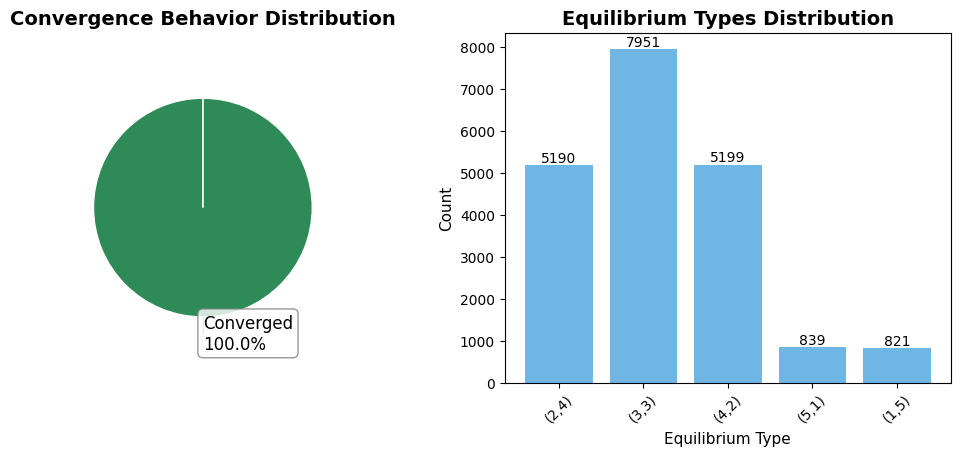

In [60]:
# Create visualizations
if 'stats' in globals():
    fig = plot_equilibrium_analysis(stats,plot_types=['convergence','distribution'],save=True,paper_figure={'paper':True,'section':'3_1_3','figure_id':'fig313_c'})
    plt.show()
else:
    print("Run the analysis first to generate visualizations.")

POSITION ANALYSIS:
Number of converged equilibria: 20000

POSITION STATISTICS:
  Mean positions: [0.49797422 0.50034153 0.5005172  0.50007117 0.5032087  0.4987897 ]
  Std positions:  [0.24669094 0.24667826 0.24668805 0.24669102 0.24666576 0.24667671]
  Min positions:  [0.25214353 0.25214353 0.25214353 0.25214353 0.25214353 0.25214353]
  Max positions:  [0.7478565 0.7478565 0.7478565 0.7478565 0.7478565 0.7478565]

EXAMPLE POSITIONS BY TYPE:
------------------------------
  Type (2,4): [0.74558514 0.74558514 0.25214353 0.74558514 0.25214353 0.74558485]
  Type (2,4): [0.25214353 0.7455849  0.7455852  0.25214353 0.7455852  0.74558485]
  Type (2,4): [0.74558514 0.25214353 0.74558514 0.25214353 0.74558514 0.74558485]
  Type (4,2): [0.2544149 0.7478565 0.2544149 0.2544151 0.2544149 0.7478565]
  Type (4,2): [0.2544149  0.25441504 0.7478565  0.25441504 0.7478565  0.25441486]
  Type (2,4): [0.74558514 0.25214353 0.74558514 0.74558485 0.25214353 0.74558514]
  Type (2,4): [0.7455849  0.7455852  0

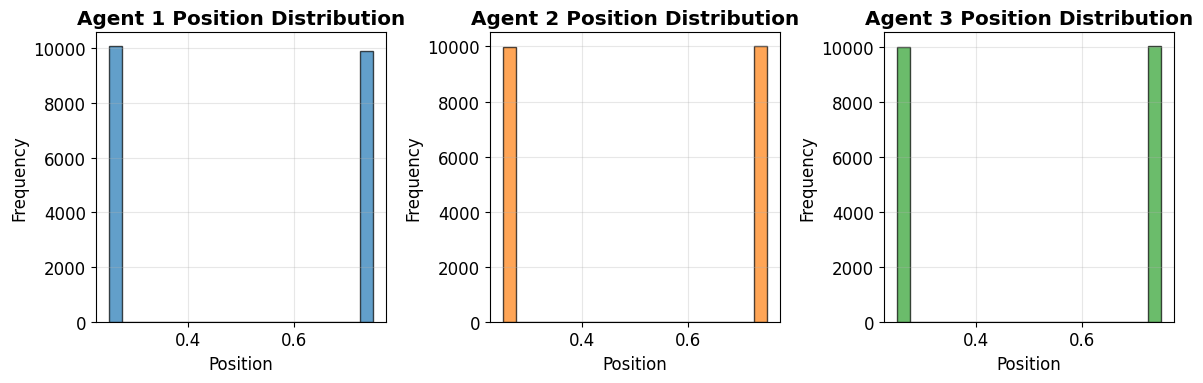

In [ ]:
def analyze_position_clusters(stats, tolerance=1e-3):
    """
    Analyze the actual position values of converged equilibria.
    """
    if not stats['convergence_positions']:
        print("No converged positions to analyze.")
        return
    
    positions = np.array(stats['convergence_positions'])
    
    print("POSITION ANALYSIS:")
    print("="*50)
    print(f"Number of converged equilibria: {len(positions)}")
    print()
    
    # Analyze position statistics
    print("POSITION STATISTICS:")
    print(f"  Mean positions: {np.mean(positions, axis=0)}")
    print(f"  Std positions:  {np.std(positions, axis=0)}")
    print(f"  Min positions:  {np.min(positions, axis=0)}")
    print(f"  Max positions:  {np.max(positions, axis=0)}")
    print()
    
    # Show some example positions for each equilibrium type
    print("EXAMPLE POSITIONS BY TYPE:")
    print("-"*30)
    
    # Fixed iteration - stats['convergence _positions'] is a list, not a dict
    for i, pos in enumerate(stats['convergence_positions'][:10]):
        eq_type = classify_equilibrium_type(pos, tolerance)
        print(f"  Type {eq_type}: {pos}")
    
    print()
    return positions

def plot_position_distribution(positions, figsize=(12, 4)):
    """
    Plot the distribution of equilibrium positions.
    """
    if len(positions) == 0:
        print("No positions to plot.")
        return
    
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    # Plot position distribution for each agent
    for i in range(min(3, positions.shape[1])):  # Handle cases with fewer than 3 agents
        ax = axes[i]
        ax.hist(positions[:, i], bins=20, alpha=0.7, color=f'C{i}', edgecolor='black')
        ax.set_title(f'Agent {i+1} Position Distribution', fontweight='bold')
        ax.set_xlabel('Position')
        ax.set_ylabel('Frequency')
        ax.grid(True, alpha=0.3)
    
    # If fewer than 3 agents, hide unused subplots
    for i in range(positions.shape[1], 3):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    return fig

# Detailed position analysis
if 'stats' in globals() and stats['convergence_positions']:
    positions = analyze_position_clusters(stats)
    fig_pos = plot_position_distribution(positions)
    plt.show()
else:
    print("No converged positions available for detailed analysis.")

Analyzing unique equilibria...
UNIQUE EQUILIBRIA ANALYSIS
Position tolerance: 0.001
Total converged points: 20000
Number of unique equilibria: 3
Compression ratio: 3/20000 = 0.000

UNIQUE EQUILIBRIA DETAILS:
----------------------------------------------------------------------
  #   Type  Count  Frequency                      Positions
----------------------------------------------------------------------
  1  (3,3)   8005      40.0% [0.253, 0.253, 0.253, 0.747, 0.747, 0.747]
  2  (2,4)   6016      30.1% [0.252, 0.252, 0.746, 0.746, 0.746, 0.746]
  3  (4,2)   5979      29.9% [0.254, 0.254, 0.254, 0.254, 0.748, 0.748]
----------------------------------------------------------------------

ANALYSIS WITH LOOSER TOLERANCE (1e-2)
UNIQUE EQUILIBRIA ANALYSIS
Position tolerance: 0.01
Total converged points: 20000
Number of unique equilibria: 3
Compression ratio: 3/20000 = 0.000

UNIQUE EQUILIBRIA DETAILS:
----------------------------------------------------------------------
  #   Type  Count

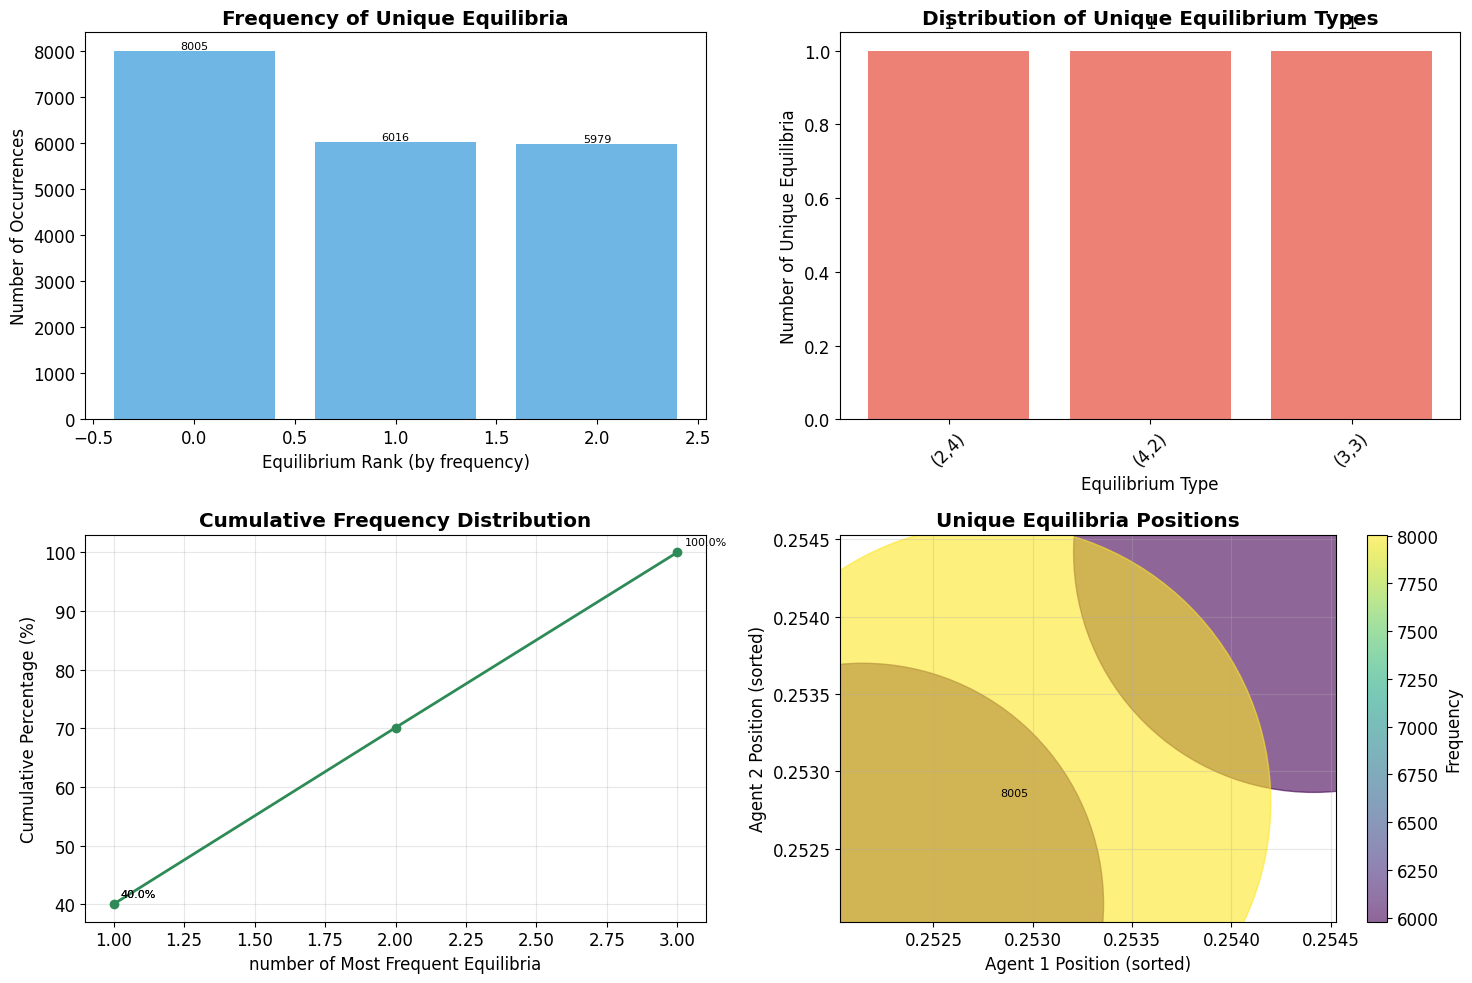

In [ ]:
def find_unique_equilibria(stats, position_tolerance=1e-3):
    """
    Find unique equilibria by clustering similar positions and count occurrences.
    
    Args:
        stats: Statistics dictionary from grid search analysis
        position_tolerance: Tolerance for considering positions as the same equilibrium
    
    Returns:
        Dictionary with unique equilibria information
    """
    if not stats['convergence_positions']:
        print("No converged positions to analyze for uniqueness.")
        return {}
    
    positions = np.array(stats['convergence_positions'])
    unique_equilibria = []
    equilibrium_counts = []
    equilibrium_types = []
    
    for pos in positions:
        # Sort positions for consistent comparison
        sorted_pos = np.sort(pos)
        
        # Check if this position is similar to any existing unique equilibrium
        is_new = True
        for i, unique_pos in enumerate(unique_equilibria):
            # Calculate L2 distance between sorted positions
            distance = np.linalg.norm(sorted_pos - unique_pos)
            if distance <= position_tolerance:
                equilibrium_counts[i] += 1
                is_new = False
                break
        
        # If it's a new unique equilibrium, add it
        if is_new:
            unique_equilibria.append(sorted_pos)
            equilibrium_counts.append(1)
            eq_type = classify_equilibrium_type(pos, position_tolerance)
            equilibrium_types.append(eq_type)
    
    return {
        'unique_positions': unique_equilibria,
        'counts': equilibrium_counts,
        'types': equilibrium_types,
        'total_unique': len(unique_equilibria),
        'total_converged': len(positions)
    }

def analyze_unique_equilibria(stats, position_tolerance=1e-3):
    """
    Comprehensive analysis of unique equilibria with detailed reporting.
    """
    unique_data = find_unique_equilibria(stats, position_tolerance)
    
    if not unique_data:
        return
    
    print("="*70)
    print("UNIQUE EQUILIBRIA ANALYSIS")
    print("="*70)
    print(f"Position tolerance: {position_tolerance}")
    print(f"Total converged points: {unique_data['total_converged']}")
    print(f"Number of unique equilibria: {unique_data['total_unique']}")
    print(f"Compression ratio: {unique_data['total_unique']}/{unique_data['total_converged']} = {unique_data['total_unique']/unique_data['total_converged']:.3f}")
    print()
    
    print("UNIQUE EQUILIBRIA DETAILS:")
    print("-" * 70)
    print(f"{'#':>3} {'Type':>6} {'Count':>6} {'Frequency':>10} {'Positions':>30}")
    print("-" * 70)
    
    # Sort by count (most frequent first)
    sorted_indices = np.argsort(unique_data['counts'])[::-1]
    
    for rank, idx in enumerate(sorted_indices, 1):
        pos = unique_data['unique_positions'][idx]
        count = unique_data['counts'][idx]
        eq_type = unique_data['types'][idx]
        frequency = count / unique_data['total_converged'] * 100
        
        # Format positions nicely
        pos_str = '[' + ', '.join([f'{p:.3f}' for p in pos]) + ']'
        
        print(f"{rank:>3} {eq_type:>6} {count:>6} {frequency:>9.1f}% {pos_str:>30}")
    
    print("-" * 70)
    return unique_data

def plot_unique_equilibria_analysis(unique_data, figsize=(15, 10)):
    """
    Create comprehensive visualizations of unique equilibria analysis.
    """
    if not unique_data:
        print("No unique equilibria data to plot.")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    
    # Plot 1: Frequency of unique equilibria (bar chart)
    ax1 = axes[0, 0]
    counts = unique_data['counts']
    sorted_indices = np.argsort(counts)[::-1]
    sorted_counts = [counts[i] for i in sorted_indices]
    
    bars = ax1.bar(range(len(sorted_counts)), sorted_counts, color='#3498DB', alpha=0.7)
    ax1.set_title('Frequency of Unique Equilibria', fontweight='bold')
    ax1.set_xlabel('Equilibrium Rank (by frequency)')
    ax1.set_ylabel('Number of Occurrences')
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{int(height)}', ha='center', va='bottom', fontsize=8)
    
    # Plot 2: Equilibrium type distribution among unique equilibria
    ax2 = axes[0, 1]
    from collections import Counter
    type_counts = Counter(unique_data['types'])
    
    if type_counts:
        types = list(type_counts.keys())
        type_frequencies = list(type_counts.values())
        
        bars = ax2.bar(types, type_frequencies, color='#E74C3C', alpha=0.7)
        ax2.set_title('Distribution of Unique Equilibrium Types', fontweight='bold')
        ax2.set_xlabel('Equilibrium Type')
        ax2.set_ylabel('Number of Unique Equilibria')
        ax2.tick_params(axis='x', rotation=45)
        
        # Add value labels
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                    f'{int(height)}', ha='center', va='bottom')
    
    # Plot 3: Cumulative frequency distribution
    ax3 = axes[1, 0]
    sorted_counts = np.sort(counts)[::-1]
    cumulative_freq = np.cumsum(sorted_counts) / np.sum(sorted_counts) * 100
    
    ax3.plot(range(1, len(cumulative_freq) + 1), cumulative_freq, 'o-', color='#2E8B57', linewidth=2)
    ax3.set_title('Cumulative Frequency Distribution', fontweight='bold')
    ax3.set_xlabel('number of Most Frequent Equilibria')
    ax3.set_ylabel('Cumulative Percentage (%)')
    ax3.grid(True, alpha=0.3)
    
    # Add percentage labels for key points
    key_points = [1, len(cumulative_freq)//4, len(cumulative_freq)//2, len(cumulative_freq)]
    for point in key_points:
        if point <= len(cumulative_freq):
            ax3.annotate(f'{cumulative_freq[point-1]:.1f}%', 
                        xy=(point, cumulative_freq[point-1]),
                        xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    # Plot 4: Position scatter plot (for 3-agent case)
    ax4 = axes[1, 1]
    if unique_data['unique_positions'] and len(unique_data['unique_positions'][0]) >= 2:
        positions = np.array(unique_data['unique_positions'])
        counts = np.array(unique_data['counts'])
        
        # Create scatter plot with size proportional to frequency
        scatter = ax4.scatter(positions[:, 0], positions[:, 1], 
                            s=counts*20, alpha=0.6, c=counts, cmap='viridis')
        
        ax4.set_title('Unique Equilibria Positions', fontweight='bold')
        ax4.set_xlabel('Agent 1 Position (sorted)')
        ax4.set_ylabel('Agent 2 Position (sorted)')
        ax4.grid(True, alpha=0.3)
        
        # Add colorbar
        cbar = plt.colorbar(scatter, ax=ax4)
        cbar.set_label('Frequency')
        
        # Add text annotations for high-frequency equilibria
        high_freq_indices = np.where(counts >= np.percentile(counts, 75))[0]
        for idx in high_freq_indices:
            ax4.annotate(f'{counts[idx]}', 
                        xy=(positions[idx, 0], positions[idx, 1]),
                        xytext=(5, 5), textcoords='offset points', fontsize=8)
    else:
        ax4.text(0.5, 0.5, 'Position visualization\nnot available\n(need 2+ dimensions)', 
                transform=ax4.transAxes, ha='center', va='center')
        ax4.set_title('Unique Equilibria Positions', fontweight='bold')
    
    plt.tight_layout()
    return fig

# Run unique equilibria analysis
if 'stats' in globals() and stats['convergence_positions']:
    print("Analyzing unique equilibria...")
    unique_data = analyze_unique_equilibria(stats, position_tolerance=1e-3)
    
    # Also try with a looser tolerance
    print("\n" + "="*70)
    print("ANALYSIS WITH LOOSER TOLERANCE (1e-2)")
    print("="*70)
    unique_data_loose = analyze_unique_equilibria(stats, position_tolerance=1e-2)
    
    # Create visualizations
    if unique_data:
        fig_unique = plot_unique_equilibria_analysis(unique_data)
        plt.show()
else:
    print("No converged positions available for unique equilibria analysis.")

In [ ]:
stop

NameError: name 'stop' is not defined

In [ ]:
def unit_cube_3d(resolution=10):
            """Generates a 3D unit cube as a torch tensor grid of points."""
            lin = torch.linspace(0, 1, resolution + 2)[1:-1]
            grid_x, grid_y, grid_z = torch.meshgrid(lin, lin, lin, indexing='ij')
            
            # Stack the coordinates to create 3D points
            points = torch.stack([grid_x, grid_y, grid_z], dim=-1).reshape(-1, 3)
            
            # Return all points without filtering
            return points

In [ ]:
def detect_approximate_cycles(sequence, tolerance=0.05, min_period=10, max_period=None):
    """
    Detect approximate cycles by looking for similar patterns with some tolerance.
    This handles cases where cycles exist but aren't exactly identical.
    """
    if max_period is None:
        max_period = len(sequence) // 3
    
    data = np.array(sequence)
    best_period = None
    best_score = 0
    
    for period in range(min_period, min(max_period, len(data) // 2)):
        scores = []
        
        # Compare segments of this period length
        for start in range(len(data) - 2 * period):
            seg1 = data[start:start + period]
            seg2 = data[start + period:start + 2 * period]
            
            # Calculate normalized correlation
            if np.std(seg1) > 1e-6 and np.std(seg2) > 1e-6:
                correlation = np.corrcoef(seg1, seg2)[0, 1]
                if not np.isnan(correlation):
                    scores.append(abs(correlation))
        
        if scores:
            avg_score = np.mean(scores)
            max_score = np.max(scores)
            
            # Combined score favoring consistency and strength
            combined_score = avg_score * max_score
            
            if combined_score > best_score and avg_score > 0.3:
                best_score = combined_score
                best_period = period
    
    return {
        'has_approximate_cycle': best_period is not None,
        'period': best_period,
        'correlation_score': best_score,
        'confidence': min(1.0, best_score) if best_period else 0
    }


In [ ]:
import time 
from InflGame.adaptive.grad_func_env import AdaptiveEnv
def grid_search_Eq(cube_points,time_steps=10000,): 
        """
        Creates an interactive 3D plot of gradient ascent paths from multiple starting points,
        with paths color-coded based on the initial position's quadrant.
        
        Args:
            vis_field: The visualization field object
            resolution (int): Resolution of the cube grid (points per dimension)
            time_steps (int): Maximum number of steps for gradient ascent
            start_color (str): Color of the starting points
            end_color (str): Color of the ending points (for converged paths)
            title (str): Plot title
            show_planes (bool): Whether to show the equality planes (x=y, y=z, z=x)
            
        Returns:
            plotly.graph_objects.Figure: Interactive 3D plot
        """
    
            
        print(f"Processing {len(cube_points)} starting points...")
        
        
        # Start timing
        start_time = time.time()

        results_dict = {}

        temp_field = AdaptiveEnv(num_agents=vis.num_agents,agents_pos=vis.agents_pos,parameters=vis.parameters,
                                             resource_distribution=vis.resource_distribution,bin_points=vis.bin_points,
                                             infl_configs=vis.infl_configs,learning_rate_type=vis.learning_rate_type,learning_rate=vis.learning_rate,time_steps=vis.time_steps,fp=vis.fp,infl_cshift=vis.infl_cshift,cshift=vis.cshift,
                                             infl_fshift=vis.infl_fshift,Q=vis.Q,domain_type=vis.domain_type,domain_bounds=vis.domain_bounds,tolerance=vis.tolerance,tolerated_agents=vis.tolerated_agents,ignore_zero_infl=vis.ignore_zero_infl) 
        # Process points sequentially (faster than parallelization due to deep copy overhead)
        for i, point in enumerate(cube_points):
            try:            
                # Reset the field's agents positions for this run
                if temp_field.num_agents != 3:
                    # we need to add number of players -3 values equal to player 2 position
                    extra_agents = temp_field.num_agents - 3
                    point_extended = point.tolist() + [point[1].item()] * extra_agents
                    temp_field.agents_pos = torch.tensor(point_extended)
                else:
                    temp_field.agents_pos = point.clone()
                temp_field.gradient_ascent()
                
                # Get the path data
                if vis.num_agents != 3:
                    pos_matrix= temp_field.pos_matrix[:, :3].numpy()  # Only take first 3 dimensions for plotting
                else:
                    pos_matrix = temp_field.pos_matrix.numpy()  # Convert to numpy for plotly
                converged = len(temp_field.pos_matrix) < time_steps
                if converged:
                    converged_pos = pos_matrix[-1]
                    results_dict[f'{i}'] = {'converged':converged,'pos_converged':converged_pos}
                else:
                    cycle_test=detect_approximate_cycles(pos_matrix[0:2000,0])
                    if cycle_test['has_approximate_cycle']:
                        results_dict[f'{i}'] = {'converged':converged,'pos_converged':'cycle'}

                


                # Update progress periodically
                if (i + 1) % 5 == 0 or (i + 1) == len(cube_points):
                    print(f"Processed {i+1}/{len(cube_points)} points ({(i+1)/len(cube_points)*100:.1f}%)")
                    
            except Exception as e:
                print(f"Error processing point {i}: {str(e)}")
        
        # End timing and report
        end_time = time.time()
        processing_time = end_time - start_time
        print(f"Processing completed in {processing_time:.2f} seconds")
        
        

In [ ]:
grid_search_Eq(cube_points=unit_cube_3d(resolution=5),time_steps=3000)

Processing 125 starting points...


KeyboardInterrupt: 